
# RQ3 Notebook — Prevalence Shift and Class Imbalance for Social Bot Detection

This notebook implements **RQ3** from the revised proposal:

> **How sensitive are bot detection models to class imbalance and realistic prevalence shifts in deployment-oriented settings?**

It is organized to go **step by step from data loading to the required RQ3 outputs**:

- **Figure RQ3-a**: performance under prevalence shift
- **Figure RQ3-b**: precision–recall behavior under deployment shift
- **Table RQ3-a**: prevalence-shift evaluation table
- **Table RQ3-b**: calibration and threshold analysis

It writes all RQ3 outputs into:

- `outputs/rq3_figures/` for figures
- `outputs/rq3_tables/` for tables

All figures are saved as **PDF** files in addition to PNG.

**Patched behavior:** this notebook tries to use **XGBoost** first and automatically falls back to
**HistGradientBoostingClassifier** if XGBoost is unavailable or broken in the local environment.


In [ ]:

# Optional dependency note:
# The graph sections require torch-geometric.
# If it is missing in your environment, install it first according to your PyTorch version:
#
# pip install torch-geometric
#
# The notebook is written so that the tabular RQ3 pipeline still runs without it.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score, balanced_accuracy_score,
    precision_recall_curve, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

XGB_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.")
    print("Import error:", e)

PYG_AVAILABLE = True
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GATConv
    from sklearn.neighbors import kneighbors_graph
except Exception as e:
    PYG_AVAILABLE = False
    print("torch-geometric is not available. Graph sections will be skipped until installed.")
    print("Import error:", e)

PRIMARY_SEED = 42

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    if PYG_AVAILABLE:
        torch.manual_seed(seed)

set_seed(PRIMARY_SEED)

DATA_PATH = Path("./Data/full_dataset.csv")
BASE_DIR = Path("")
OUT_DIR = BASE_DIR / "outputs"
RQ3_FIG_DIR = OUT_DIR / "rq3_figures"
RQ3_TABLE_DIR = OUT_DIR / "rq3_tables"
RQ3_FIG_DIR.mkdir(parents=True, exist_ok=True)
RQ3_TABLE_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = [
    "followers_count", "friends_count", "statuses_count",
    "favourites_count", "listed_count"
]
BINARY_FEATURES = [
    "default_profile", "default_profile_image", "geo_enabled"
]
MISSINGNESS_FEATURES = [
    "default_profile_missing", "default_profile_image_missing", "geo_enabled_missing"
]
REVISED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + MISSINGNESS_FEATURES

print("Ready.")
print("Dataset path:", DATA_PATH)
print("Figure output dir:", RQ3_FIG_DIR)
print("Table output dir:", RQ3_TABLE_DIR)


XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.
Import error: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (n

## 1. Load the dataset and create the revised 11-feature policy

In [2]:

df = pd.read_csv(DATA_PATH, low_memory=False)
required_cols = ["label"] + NUMERIC_FEATURES + BINARY_FEATURES
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_work = df.copy()
for col in BINARY_FEATURES:
    df_work[f"{col}_missing"] = df_work[col].isna().astype(int)

dataset_summary = {
    "shape": list(df_work.shape),
    "label_distribution": df_work["label"].value_counts(dropna=False).to_dict(),
    "missingness": df_work[NUMERIC_FEATURES + BINARY_FEATURES].isna().mean().round(4).to_dict()
}

print("Shape:", df_work.shape)
print("Label distribution:", dataset_summary["label_distribution"])
display(pd.DataFrame([dataset_summary["missingness"]]))
display(df_work[REVISED_FEATURES + ["label"]].head())


Shape: (14368, 46)
Label distribution: {1: 10894, 0: 3474}


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled
0,0.0,0.0,0.0,0.0,0.0,0.686,0.9946,0.7611


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing,label
0,657,534,236,0,44,NaN,NaN,1.0,1,1,0,1
1,15,30,129,0,0,NaN,NaN,NaN,1,1,1,1
2,42,387,1,0,1,NaN,NaN,NaN,1,1,1,1
3,226,598,1,0,1,NaN,NaN,NaN,1,1,1,1
4,67,474,348,6,0,1.0,NaN,NaN,0,1,1,1


## 2. Define preprocessing, metrics, prevalence-shift, and calibration helpers

In [3]:

def compute_metrics(y_true, y_pred, y_prob=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def preprocess_split_with_val(df_in, seed=42):
    X = df_in[REVISED_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.125, stratify=y_train_val, random_state=seed
    )

    num_imputer = SimpleImputer(strategy="median")
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
    X_val_num = pd.DataFrame(num_imputer.transform(X_val[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_val.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_bin = X_train[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_val_bin = X_val[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_test_bin = X_test[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=NUMERIC_FEATURES, index=X_train.index)
    X_val_num_scaled = pd.DataFrame(scaler.transform(X_val_num), columns=NUMERIC_FEATURES, index=X_val.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_all = pd.concat([X_train_num_scaled, X_train_bin], axis=1)[REVISED_FEATURES]
    X_val_all = pd.concat([X_val_num_scaled, X_val_bin], axis=1)[REVISED_FEATURES]
    X_test_all = pd.concat([X_test_num_scaled, X_test_bin], axis=1)[REVISED_FEATURES]

    return {
        "X_train": X_train_all,
        "X_val": X_val_all,
        "X_test": X_test_all,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }

def get_models(seed=42):
    if XGB_AVAILABLE:
        xgb_model = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed
        )
        xgb_name = "XGBoost"
    else:
        xgb_model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=seed
        )
        xgb_name = "HistGradientBoosting"

    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed),
        xgb_name: xgb_model
    }

def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = np.asarray(model.decision_function(X)).reshape(-1)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)

def create_prevalence_shift_subset(X_test, y_test, prevalence=0.5, seed=42):
    rng = np.random.default_rng(seed)
    df_test = X_test.copy()
    df_test["label"] = y_test.values

    fake_df = df_test[df_test["label"] == 1]
    real_df = df_test[df_test["label"] == 0]

    # Keep all real users, downsample fake users to target prevalence
    n_real = len(real_df)
    target_fake = int((prevalence / max(1e-9, (1 - prevalence))) * n_real)
    target_fake = max(1, min(target_fake, len(fake_df)))

    fake_sample = fake_df.sample(n=target_fake, random_state=seed, replace=False)
    combined = pd.concat([real_df, fake_sample], axis=0).sample(frac=1.0, random_state=seed)

    return combined.drop(columns=["label"]), combined["label"]

def select_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 37)
    best_t, best_f1 = 0.5, -1
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, pred)
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t, best_f1

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.any(mask):
            acc = np.mean(y_true[mask] == (y_prob[mask] >= 0.5).astype(int))
            conf = np.mean(y_prob[mask])
            ece += np.mean(mask) * abs(acc - conf)
    return float(ece)

print("Helpers defined.")


Helpers defined.


## 3. Train the main tabular models on the official split

In [4]:

pack = preprocess_split_with_val(df_work, PRIMARY_SEED)

trained_models = {}
main_rows = []

for model_name, model in get_models(PRIMARY_SEED).items():
    t0 = time.time()
    model.fit(pack["X_train"], pack["y_train"])
    y_prob = get_probabilities(model, pack["X_test"])
    y_pred = (y_prob >= 0.5).astype(int)
    elapsed = time.time() - t0
    met = compute_metrics(pack["y_test"], y_pred, y_prob)
    met.update({"Model": model_name, "Runtime (s)": elapsed, "Family": "Tabular"})
    main_rows.append(met)
    trained_models[model_name] = model

main_tabular = pd.DataFrame(main_rows)
display(main_tabular)


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Runtime (s),Family
0,0.926931,0.890085,0.944106,0.856270,0.973763,0.795542,0.856270,Logistic Regression,0.020077,Tabular
1,0.984690,0.979083,0.980031,0.978145,0.998407,0.958174,0.978145,HistGradientBoosting,0.831448,Tabular



## 4. Optional graph candidate for RQ3

If `torch-geometric` is available, this section trains a **GAT** model to serve as the graph-based comparator for prevalence-shift analysis.


In [5]:

if PYG_AVAILABLE:
    class GATNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=16, heads=2):
            super().__init__()
            self.conv1 = GATConv(in_dim, hidden, heads=heads, dropout=0.2)
            self.conv2 = GATConv(hidden * heads, 2, heads=1, concat=False, dropout=0.2)

        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = F.elu(self.conv1(x, edge_index))
            x = self.conv2(x, edge_index)
            return x

    def build_graph_data(X_train_df, X_val_df, X_test_df, y_train, y_val, y_test, k=5, metric="cosine"):
        X_all = pd.concat([X_train_df, X_val_df, X_test_df], axis=0)
        y_all = pd.concat([y_train, y_val, y_test], axis=0)

        adj = kneighbors_graph(X_all.values, n_neighbors=k, metric=metric, include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=y)
        n_train = len(X_train_df)
        n_val = len(X_val_df)

        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        val_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)

        train_mask[:n_train] = True
        val_mask[n_train:n_train+n_val] = True
        test_mask[n_train+n_val:] = True

        data.train_mask = train_mask
        data.val_mask = val_mask
        data.test_mask = test_mask
        return data

    def train_gat_and_probs(data, epochs=120, lr=0.01):
        model = GATNet(data.num_node_features, hidden=16, heads=2)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = torch.nn.CrossEntropyLoss()

        for _ in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

        model.eval()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        preds = out.argmax(dim=1).detach().cpu().numpy()
        return model, probs, preds

    graph_data = build_graph_data(
        pack["X_train"], pack["X_val"], pack["X_test"],
        pack["y_train"], pack["y_val"], pack["y_test"],
        k=5, metric="cosine"
    )
    gat_model, gat_all_probs, gat_all_preds = train_gat_and_probs(graph_data, epochs=100, lr=0.01)

    n_train = len(pack["X_train"])
    n_val = len(pack["X_val"])
    gat_test_prob = gat_all_probs[n_train+n_val:]
    gat_test_pred = gat_all_preds[n_train+n_val:]
    gat_test_true = pack["y_test"].values

    gat_metrics = compute_metrics(gat_test_true, gat_test_pred, gat_test_prob)
    gat_metrics.update({"Model": "GAT", "Family": "Graph-based"})
    display(pd.DataFrame([gat_metrics]))
else:
    gat_model = None
    gat_all_probs = None
    gat_test_prob = None
    gat_test_true = None
    print("Graph section skipped because torch-geometric is not installed.")


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Family
0,0.924843,0.888816,0.931066,0.860283,0.979381,0.788177,0.860283,GAT,Graph-based



## 5. Optional hybrid model for RQ3

If the graph section is available, this section constructs a compact **hybrid tabular + graph-posterior** representation for prevalence-shift comparison.


In [6]:

if PYG_AVAILABLE and gat_model is not None:
    n_train = len(pack["X_train"])
    n_val = len(pack["X_val"])
    n_test = len(pack["X_test"])

    train_prob_feat = pd.DataFrame({"gat_prob": gat_all_probs[:n_train]}, index=pack["X_train"].index)
    val_prob_feat = pd.DataFrame({"gat_prob": gat_all_probs[n_train:n_train+n_val]}, index=pack["X_val"].index)
    test_prob_feat = pd.DataFrame({"gat_prob": gat_all_probs[n_train+n_val:]}, index=pack["X_test"].index)

    X_train_h = pd.concat([pack["X_train"], train_prob_feat], axis=1)
    X_val_h = pd.concat([pack["X_val"], val_prob_feat], axis=1)
    X_test_h = pd.concat([pack["X_test"], test_prob_feat], axis=1)

    if XGB_AVAILABLE:
        hybrid_model = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=PRIMARY_SEED
        )
        hybrid_name = "Hybrid XGB+GNN"
    else:
        hybrid_model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=PRIMARY_SEED
        )
        hybrid_name = "Hybrid HGB+GNN"

    hybrid_model.fit(X_train_h, pack["y_train"])
    hybrid_test_prob = get_probabilities(hybrid_model, X_test_h)
    hybrid_test_pred = (hybrid_test_prob >= 0.5).astype(int)

    hybrid_metrics = compute_metrics(pack["y_test"], hybrid_test_pred, hybrid_test_prob)
    hybrid_metrics.update({"Model": hybrid_name, "Family": "Hybrid"})
    display(pd.DataFrame([hybrid_metrics]))
else:
    hybrid_model = None
    hybrid_test_prob = None
    hybrid_name = None
    print("Hybrid section skipped because graph section is unavailable.")


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy,Model,Family
0,0.98469,0.979145,0.978678,0.979614,0.999266,0.958292,0.979614,Hybrid HGB+GNN,Hybrid


## 6. Build Table RQ3-a: prevalence-shift evaluation

In [7]:

prevalences = [0.50, 0.20, 0.10, 0.05]
rows = []

# Logistic Regression
lr_model = trained_models["Logistic Regression"]
for prev in prevalences:
    X_sub, y_sub = create_prevalence_shift_subset(pack["X_test"], pack["y_test"], prevalence=prev, seed=PRIMARY_SEED)
    prob = get_probabilities(lr_model, X_sub)
    pred = (prob >= 0.5).astype(int)
    met = compute_metrics(y_sub, pred, prob)
    rows.append({
        "Model": "Logistic Regression",
        "Fake Prevalence": f"{int(prev*100)}%",
        "Macro-F1": met["Macro-F1"],
        "PR-AUC": met["PR-AUC"],
        "MCC": met["MCC"],
        "Precision": precision_score(y_sub, pred, zero_division=0),
        "Recall": recall_score(y_sub, pred, zero_division=0),
    })

# Graph model
if PYG_AVAILABLE and gat_test_prob is not None:
    for prev in prevalences:
        X_sub, y_sub = create_prevalence_shift_subset(pack["X_test"], pack["y_test"], prevalence=prev, seed=PRIMARY_SEED)
        idx = X_sub.index
        prob = pd.Series(gat_test_prob, index=pack["X_test"].index).loc[idx].values
        pred = (prob >= 0.5).astype(int)
        met = compute_metrics(y_sub, pred, prob)
        rows.append({
            "Model": "GAT",
            "Fake Prevalence": f"{int(prev*100)}%",
            "Macro-F1": met["Macro-F1"],
            "PR-AUC": met["PR-AUC"],
            "MCC": met["MCC"],
            "Precision": precision_score(y_sub, pred, zero_division=0),
            "Recall": recall_score(y_sub, pred, zero_division=0),
        })

# Hybrid model
if hybrid_model is not None:
    for prev in prevalences:
        X_sub, y_sub = create_prevalence_shift_subset(pack["X_test"], pack["y_test"], prevalence=prev, seed=PRIMARY_SEED)
        idx = X_sub.index
        prob_feat = pd.DataFrame({"gat_prob": pd.Series(gat_all_probs[n_train+n_val:], index=pack["X_test"].index)}).loc[idx]
        X_sub_h = pd.concat([X_sub, prob_feat], axis=1)
        prob = get_probabilities(hybrid_model, X_sub_h)
        pred = (prob >= 0.5).astype(int)
        met = compute_metrics(y_sub, pred, prob)
        rows.append({
            "Model": hybrid_name,
            "Fake Prevalence": f"{int(prev*100)}%",
            "Macro-F1": met["Macro-F1"],
            "PR-AUC": met["PR-AUC"],
            "MCC": met["MCC"],
            "Precision": precision_score(y_sub, pred, zero_division=0),
            "Recall": recall_score(y_sub, pred, zero_division=0),
        })

rq3_table_a = pd.DataFrame(rows)
table_a_path = RQ3_TABLE_DIR / "table_rq3_a_prevalence_shift_evaluation.csv"
rq3_table_a.to_csv(table_a_path, index=False)

display(rq3_table_a)
print("Saved:", table_a_path)


,Model,Fake Prevalence,Macro-F1,PR-AUC,MCC,Precision,Recall
0,Logistic Regression,50%,0.853376,0.923346,0.740437,0.779661,0.992806
1,Logistic Regression,20%,0.734965,0.727855,0.572628,0.467213,0.988439
2,Logistic Regression,10%,0.636451,0.577213,0.443515,0.280443,0.987013
3,Logistic Regression,5%,0.553242,0.439888,0.334840,0.155844,1.000000
4,GAT,50%,0.858915,0.939538,0.746350,0.788506,0.987050
5,GAT,20%,0.745244,0.774434,0.583583,0.480226,0.982659
6,GAT,10%,0.648883,0.654608,0.457944,0.292308,0.987013
7,GAT,5%,0.564340,0.532499,0.346863,0.163636,1.000000
8,Hybrid HGB+GNN,50%,0.982731,0.998584,0.965792,0.970547,0.995683
9,Hybrid HGB+GNN,20%,0.963720,0.997418,0.929950,0.891753,1.000000


Saved: outputs/rq3_tables/table_rq3_a_prevalence_shift_evaluation.csv


## 7. Generate Figure RQ3-a: effect of deployment-oriented prevalence shift

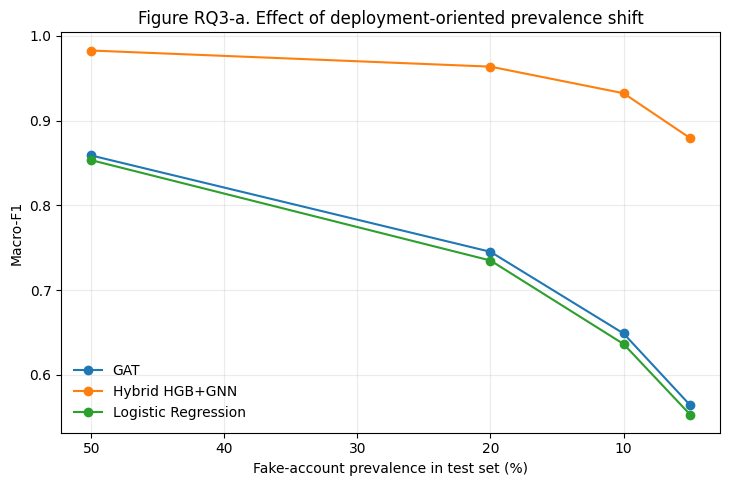

Saved:
outputs/rq3_figures/figure_rq3_a_prevalence_shift.png
outputs/rq3_figures/figure_rq3_a_prevalence_shift.pdf


In [8]:

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for model_name, sub in rq3_table_a.groupby("Model"):
    x = [int(v.replace("%", "")) for v in sub["Fake Prevalence"]]
    y = sub["Macro-F1"].values
    ax.plot(x, y, marker="o", label=model_name)

ax.invert_xaxis()
ax.set_xlabel("Fake-account prevalence in test set (%)")
ax.set_ylabel("Macro-F1")
ax.set_title("Figure RQ3-a. Effect of deployment-oriented prevalence shift")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig_a_png = RQ3_FIG_DIR / "figure_rq3_a_prevalence_shift.png"
fig_a_pdf = RQ3_FIG_DIR / "figure_rq3_a_prevalence_shift.pdf"
fig.savefig(fig_a_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_a_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_a_png)
print(fig_a_pdf)


## 8. Build Table RQ3-b: calibration and threshold analysis

In [9]:

cal_rows = []

model_specs = []

xgb_key = "XGBoost" if "XGBoost" in trained_models else ("HistGradientBoosting" if "HistGradientBoosting" in trained_models else None)
if xgb_key is not None:
    model_specs.append((xgb_key, "tabular"))

if PYG_AVAILABLE and gat_test_prob is not None:
    model_specs.append(("GAT", "graph"))

if hybrid_model is not None and hybrid_name is not None:
    model_specs.append((hybrid_name, "hybrid"))

# Validation-based threshold selection
val_probs = {}

for name, kind in model_specs:
    if kind == "tabular":
        val_probs[name] = get_probabilities(trained_models[name], pack["X_val"])
    elif kind == "graph":
        val_probs[name] = gat_all_probs[n_train:n_train+n_val]
    else:
        X_val_h = pd.concat([pack["X_val"], val_prob_feat], axis=1)
        val_probs[name] = get_probabilities(hybrid_model, X_val_h)

for name, kind in model_specs:
    best_t, _ = select_best_threshold(pack["y_val"].values, np.asarray(val_probs[name]))
    for prev in prevalences:
        X_sub, y_sub = create_prevalence_shift_subset(pack["X_test"], pack["y_test"], prevalence=prev, seed=PRIMARY_SEED)
        idx = X_sub.index

        if kind == "tabular":
            prob = get_probabilities(trained_models[name], X_sub)
        elif kind == "graph":
            prob = pd.Series(gat_test_prob, index=pack["X_test"].index).loc[idx].values
        else:
            prob_feat = pd.DataFrame({"gat_prob": pd.Series(gat_all_probs[n_train+n_val:], index=pack["X_test"].index)}).loc[idx]
            X_sub_h = pd.concat([X_sub, prob_feat], axis=1)
            prob = get_probabilities(hybrid_model, X_sub_h)

        pred_default = (prob >= 0.5).astype(int)
        pred_tuned = (prob >= best_t).astype(int)

        cal_rows.append({
            "Model": name,
            "Prevalence": f"{int(prev*100)}%",
            "Brier Score": brier_score_loss(y_sub, prob),
            "Expected Calibration Error": expected_calibration_error(np.asarray(y_sub), np.asarray(prob)),
            "Default Threshold F1": f1_score(y_sub, pred_default),
            "Tuned Threshold F1": f1_score(y_sub, pred_tuned),
            "Threshold Selected": best_t
        })

rq3_table_b = pd.DataFrame(cal_rows)
table_b_path = RQ3_TABLE_DIR / "table_rq3_b_calibration_threshold_analysis.csv"
rq3_table_b.to_csv(table_b_path, index=False)

display(rq3_table_b)
print("Saved:", table_b_path)


,Model,Prevalence,Brier Score,Expected Calibration Error,Default Threshold F1,Tuned Threshold F1,Threshold Selected
0,HistGradientBoosting,50%,0.014406,0.481402,0.981586,0.981586,0.45
1,HistGradientBoosting,20%,0.020092,0.774180,0.935135,0.935135,0.45
2,HistGradientBoosting,10%,0.022175,0.871848,0.865169,0.865169,0.45
3,HistGradientBoosting,5%,0.023418,0.920802,0.750000,0.750000,0.45
4,GAT,50%,0.106056,0.401779,0.876677,0.910798,0.70
5,GAT,20%,0.159148,0.669882,0.645161,0.733624,0.70
6,GAT,10%,0.175432,0.767516,0.451039,0.562963,0.70
7,GAT,5%,0.183505,0.815884,0.281250,0.380952,0.70
8,Hybrid HGB+GNN,50%,0.013802,0.478996,0.982955,0.981508,0.55
9,Hybrid HGB+GNN,20%,0.018930,0.770362,0.942779,0.939891,0.55


Saved: outputs/rq3_tables/table_rq3_b_calibration_threshold_analysis.csv


## 9. Generate Figure RQ3-b: precision–recall behavior under deployment shift

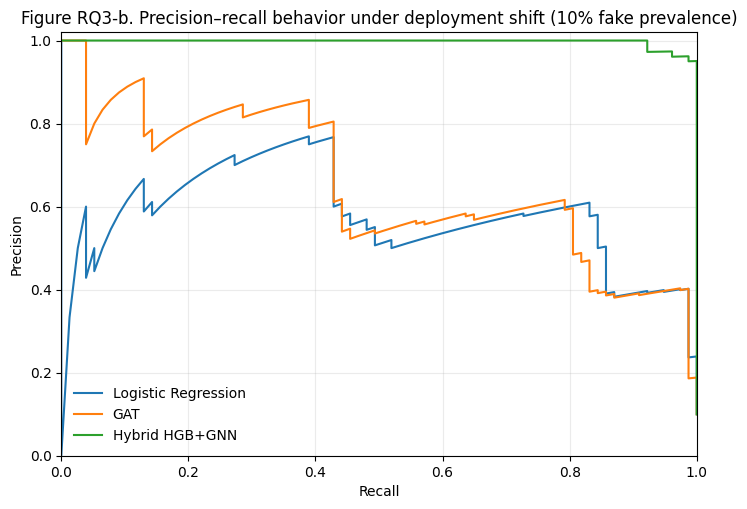

Saved:
outputs/rq3_figures/figure_rq3_b_precision_recall_shift.png
outputs/rq3_figures/figure_rq3_b_precision_recall_shift.pdf


In [10]:

fig, ax = plt.subplots(figsize=(8.2, 5.5))

target_prev = 0.10
X_sub, y_sub = create_prevalence_shift_subset(pack["X_test"], pack["y_test"], prevalence=target_prev, seed=PRIMARY_SEED)
idx = X_sub.index

# Logistic Regression
prob = get_probabilities(lr_model, X_sub)
p, r, _ = precision_recall_curve(y_sub, prob)
ax.plot(r, p, label="Logistic Regression")

# Graph model
if PYG_AVAILABLE and gat_test_prob is not None:
    prob = pd.Series(gat_test_prob, index=pack["X_test"].index).loc[idx].values
    p, r, _ = precision_recall_curve(y_sub, prob)
    ax.plot(r, p, label="GAT")

# Hybrid
if hybrid_model is not None:
    prob_feat = pd.DataFrame({"gat_prob": pd.Series(gat_all_probs[n_train+n_val:], index=pack["X_test"].index)}).loc[idx]
    X_sub_h = pd.concat([X_sub, prob_feat], axis=1)
    prob = get_probabilities(hybrid_model, X_sub_h)
    p, r, _ = precision_recall_curve(y_sub, prob)
    ax.plot(r, p, label=hybrid_name)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title("Figure RQ3-b. Precision–recall behavior under deployment shift (10% fake prevalence)")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig_b_png = RQ3_FIG_DIR / "figure_rq3_b_precision_recall_shift.png"
fig_b_pdf = RQ3_FIG_DIR / "figure_rq3_b_precision_recall_shift.pdf"
fig.savefig(fig_b_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_b_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_b_png)
print(fig_b_pdf)


## 10. Save a compact RQ3 summary JSON

In [11]:

summary = {
    "dataset_summary": dataset_summary,
    "table_rq3_a": str(table_a_path),
    "table_rq3_b": str(table_b_path),
    "figure_rq3_a": str(RQ3_FIG_DIR / "figure_rq3_a_prevalence_shift.pdf"),
    "figure_rq3_b": str(RQ3_FIG_DIR / "figure_rq3_b_precision_recall_shift.pdf"),
    "xgboost_available": bool(XGB_AVAILABLE),
    "pyg_available": bool(PYG_AVAILABLE)
}

summary_path = RQ3_TABLE_DIR / "rq3_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)
summary


Saved summary to: outputs/rq3_tables/rq3_summary.json


{'dataset_summary': {'shape': [14368, 46],
  'label_distribution': {1: 10894, 0: 3474},
  'missingness': {'followers_count': 0.0,
   'friends_count': 0.0,
   'statuses_count': 0.0,
   'favourites_count': 0.0,
   'listed_count': 0.0,
   'default_profile': 0.686,
   'default_profile_image': 0.9946,
   'geo_enabled': 0.7611}},
 'table_rq3_a': 'outputs/rq3_tables/table_rq3_a_prevalence_shift_evaluation.csv',
 'table_rq3_b': 'outputs/rq3_tables/table_rq3_b_calibration_threshold_analysis.csv',
 'figure_rq3_a': 'outputs/rq3_figures/figure_rq3_a_prevalence_shift.pdf',
 'figure_rq3_b': 'outputs/rq3_figures/figure_rq3_b_precision_recall_shift.pdf',
 'xgboost_available': False,
 'pyg_available': True}


## 11. What this notebook produces for RQ3

After running the notebook, you will have:

### Tables
- `table_rq3_a_prevalence_shift_evaluation.csv`
- `table_rq3_b_calibration_threshold_analysis.csv`

### Figures
- `figure_rq3_a_prevalence_shift.pdf`
- `figure_rq3_b_precision_recall_shift.pdf`

### Notes
- The **tabular RQ3 pipeline runs immediately**.
- The **graph and hybrid sections require `torch-geometric`**.
- The notebook already includes an **XGBoost fallback**.
